In [1]:
from main_experiment import *
from algorithms import *
from simulation import *
from TransPCA_GPU import * 

# Example usage
if __name__ == "__main__":
    # Experiment settings
    K = 10  
    n = 500
    p = 30
    rs = 2
    rp = 2
    g_types = ["mix"] + ['quadratic']*3 + ['log']*3 + ['mix']*3 # the first one is the target
    
    # Run experiment
    strategy_df, subspace_df = run_experiment(
        K=K, n=n, p=p, rs=rs, rp=rp,
        g_types=g_types,
        replications=5,
        random_state=42
    )
    
    
    print("Experiment completed.")

Experiment completed.


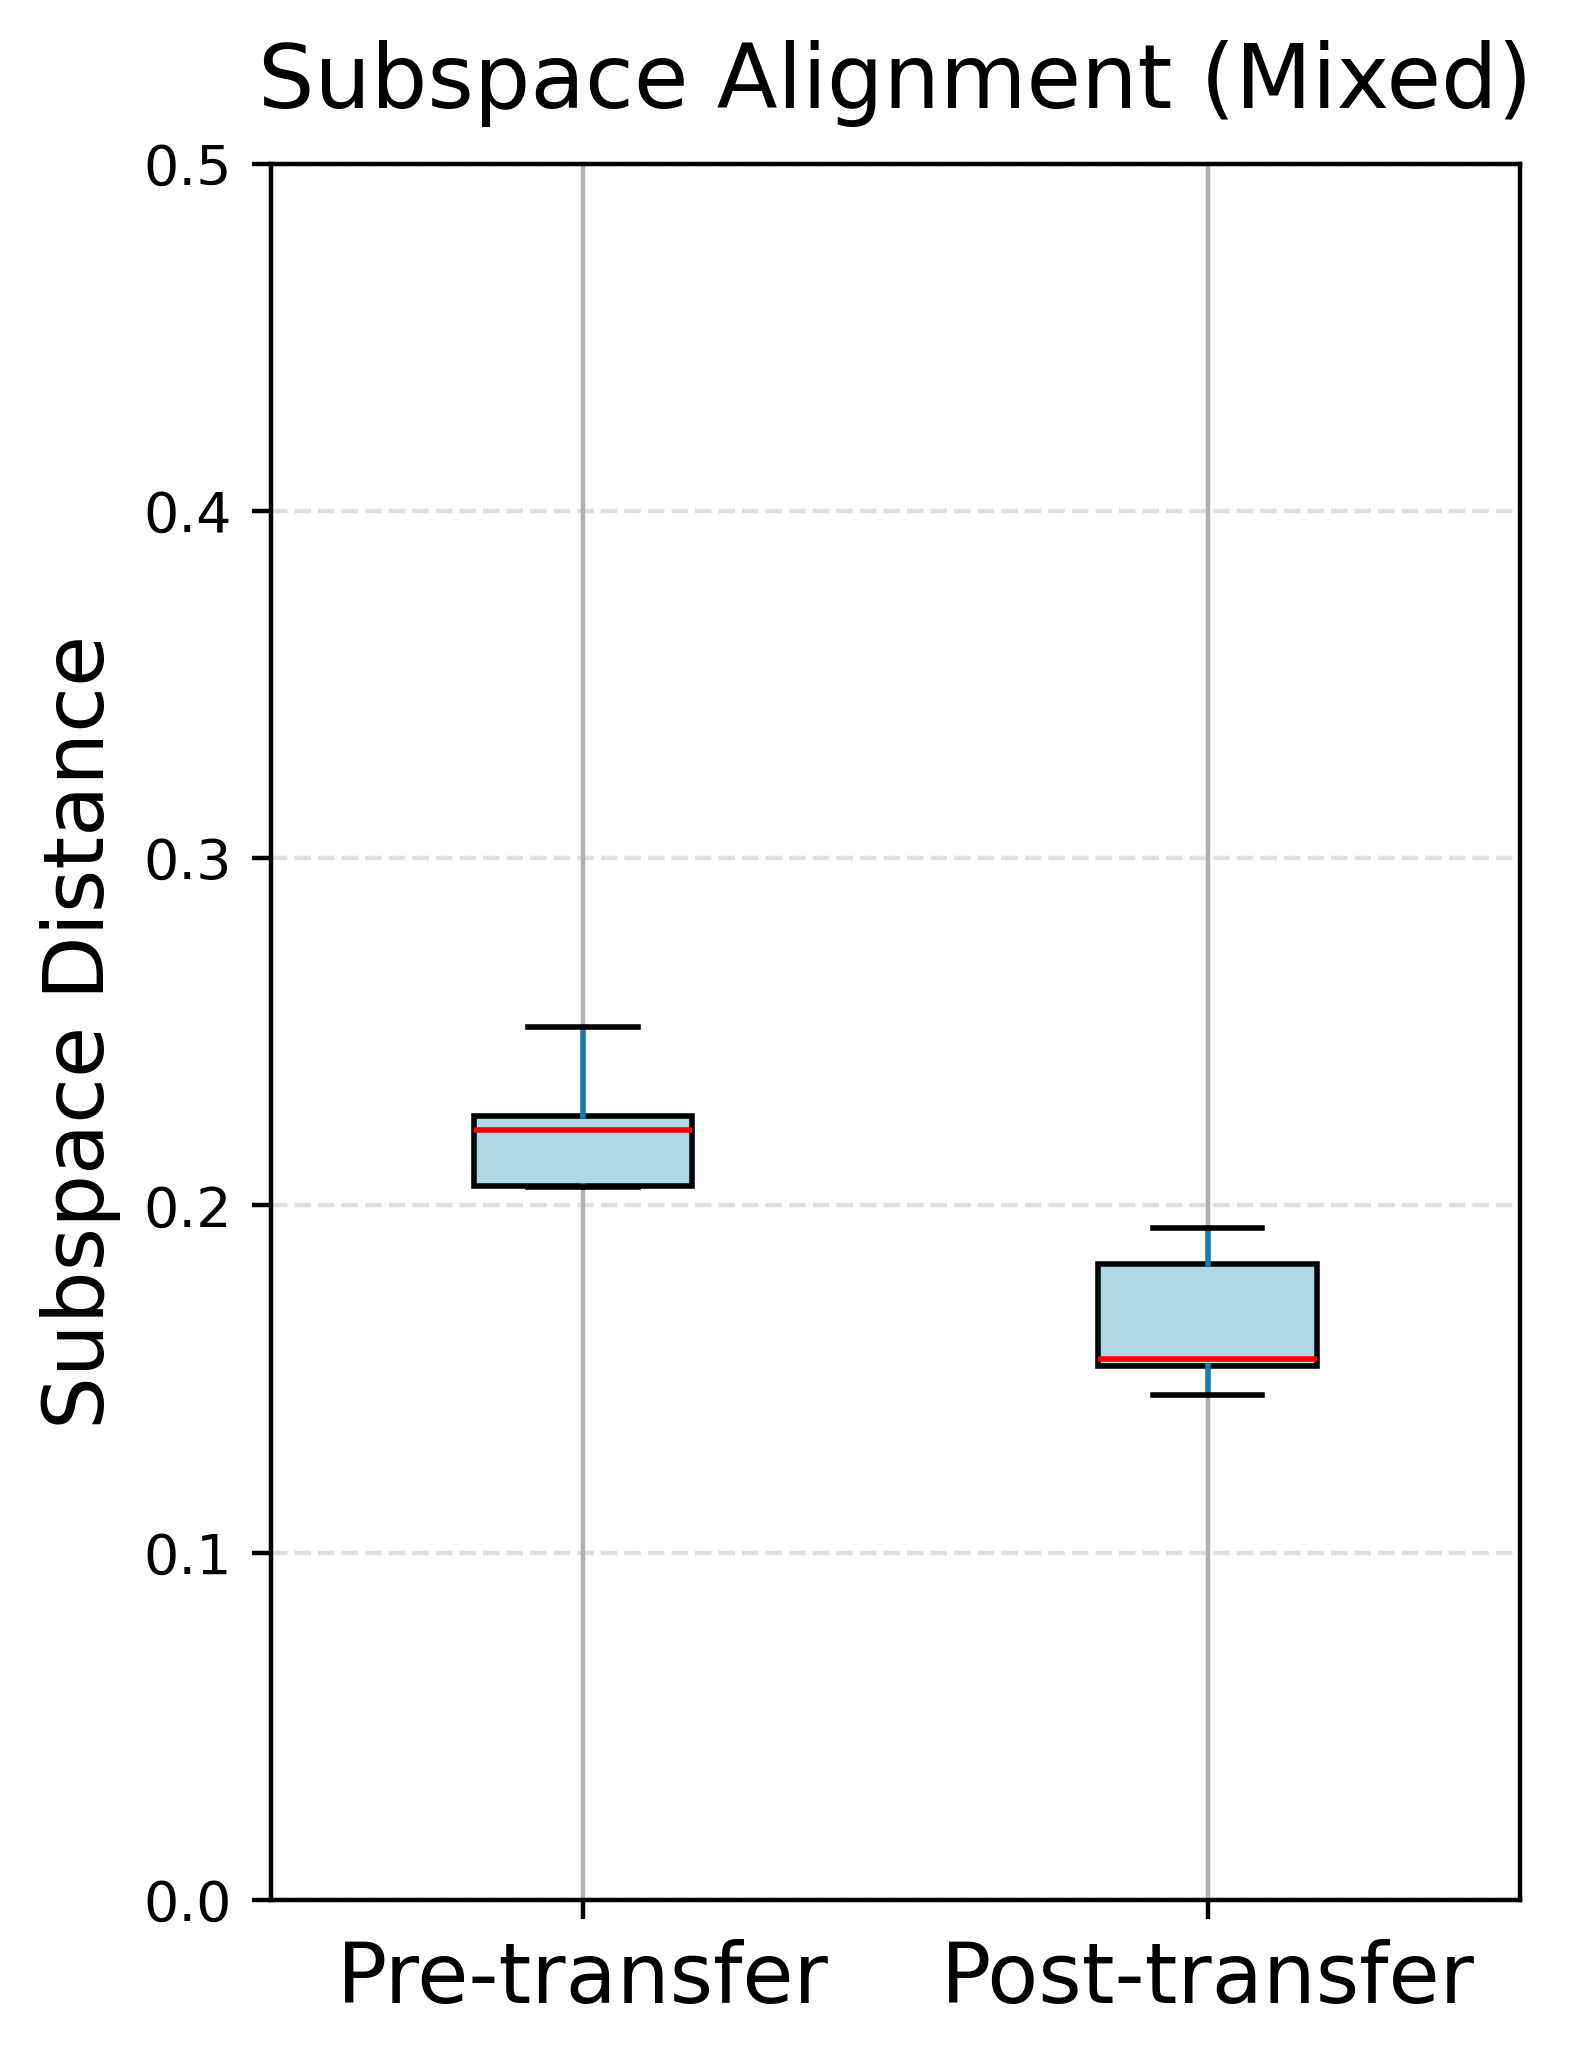

In [2]:
import matplotlib.pyplot as plt
def plot_subspace_distances(subspace_df, title):
    """
    Create a boxplot comparing subspace distances before and after transfer
    
    Args:
        subspace_df: DataFrame containing distance metrics
    """
    plt.figure(figsize=(4, 5.25), dpi=400)
    
    # Create boxplot with custom labels
    ax = subspace_df[['Direct_Subspace_Distance', 'Transfer_Subspace_Distance']].boxplot(
        positions=[0, 1],
        widths=0.35,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='red')
    )
    
    # Customize plot
    plt.ylim(0, 0.5)
    plt.xticks([0, 1], ['Pre-transfer', 'Post-transfer'],fontsize=15)
    plt.ylabel('Subspace Distance', fontsize=15)
    plt.title('Subspace Alignment (' + title +')', fontsize=16, pad=10)
    
    # Add grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()

plot_subspace_distances(subspace_df, 'Mixed')

In [3]:
def print_performance_table(strategy_df):
    """
    Print performance metrics (mean ± std) for each model and strategy
    
    Args:
        strategy_df: DataFrame containing strategy comparison results
    """
    # Calculate metrics - results in MultiIndex columns
    metrics = strategy_df.groupby(['Strategy', 'Model']).agg({
        'Train R²': ['mean', 'std'],
        'Test R²': ['mean', 'std']
    })
    
    # Flatten the MultiIndex columns
    metrics.columns = ['_'.join(col).strip() for col in metrics.columns.values]
    metrics = metrics.reset_index()
    
    # Format strings
    metrics['Train_R2'] = metrics.apply(
        lambda row: f"{row['Train R²_mean']:.3f} ± {row['Train R²_std']:.3f}", 
        axis=1
    )
    metrics['Test_R2'] = metrics.apply(
        lambda row: f"{row['Test R²_mean']:.3f} ± {row['Test R²_std']:.3f}", 
        axis=1
    )
    
    # Create pivot tables
    train_table = metrics.pivot(
        index='Model', 
        columns='Strategy', 
        values='Train_R2'
    )
    test_table = metrics.pivot(
        index='Model', 
        columns='Strategy', 
        values='Test_R2'
    )
    
    # Print results
    print("=== Training R² Scores (mean ± std) ===")
    print(train_table.to_string())
    print("\n=== Test R² Scores (mean ± std) ===")
    print(test_table.to_string())

print_performance_table(strategy_df)

=== Training R² Scores (mean ± std) ===
Strategy                      Pooled Data    Target Only Target Subspace Transfer Subspace
Model                                                                                     
Kernel Ridge (Exponential)  0.745 ± 0.002  0.680 ± 0.007   0.865 ± 0.005     0.871 ± 0.009
MLPRegressor                0.533 ± 0.012  0.854 ± 0.021   0.852 ± 0.016     0.845 ± 0.014
Random Forest               0.874 ± 0.003  0.878 ± 0.009   0.972 ± 0.003     0.969 ± 0.003
Ridge Regression            0.009 ± 0.001  0.139 ± 0.028   0.090 ± 0.032     0.087 ± 0.031
Support Vector Regression   0.699 ± 0.013  0.928 ± 0.006   0.960 ± 0.004     0.967 ± 0.003

=== Test R² Scores (mean ± std) ===
Strategy                       Pooled Data     Target Only Target Subspace Transfer Subspace
Model                                                                                       
Kernel Ridge (Exponential)   0.121 ± 0.036  -0.214 ± 0.122   0.730 ± 0.040     0.754 ± 0.052
MLPRegr